In [7]:
import sys

# 1. On force l'installation de TOUT d'un coup, exactement là où Jupyter travaille
print("Installation en cours...")
!{sys.executable} -m pip install -q pyspark==3.5.0 pandas seaborn scikit-learn matplotlib numpy

print("\n--- TEST DES IMPORTS ---")
try:
    import pandas as pd
    import seaborn as sns
    import pyspark
    print(" Pandas : OK")
    print(" Seaborn : OK")
    print(" PySpark : OK")
    print("\nTout est prêt.")
except Exception as e:
    print(f" Il reste un souci : {e}")

Installation en cours...

--- TEST DES IMPORTS ---
 Pandas : OK
 Seaborn : OK
 PySpark : OK

Tout est prêt.


In [8]:
# Phase 1: Initialisation & Chargement des données
# Etape 1: Importation des librairies

# 1. Configuration système et session Spark
import os
from pyspark.sql import SparkSession

# 2. Manipulation de données et fonctions SQL
from pyspark.sql import functions as F
from pyspark.sql.types import *

# 3. Machine Learning : Préparation des données
from pyspark.ml.feature import VectorAssembler, StandardScaler

# 4. Machine Learning : Algorithmes
from pyspark.ml.clustering import KMeans, GaussianMixture, BisectingKMeans
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression

# 5. Évaluation et Optimisation des modèles
from pyspark.ml.evaluation import ClusteringEvaluator, MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.types import FloatType

# 6. Visualisation graphique et Matrices
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report # pour le rapport final

In [9]:
#ÉTAPE 2 : Initialisation de la session
#spark = SparkSession.builder \
#    .appName("Projet_Ecommerce") \
#    .master("local[*]") \
#    .getOrCreate()


In [10]:
from pyspark.sql import SparkSession
from pyspark import SparkConf

conf = SparkConf() \
    .setMaster("local[*]") \
    .setAppName("Projet_Ecommerce") \
    .set("spark.driver.host", "127.0.0.1") \
    .set("spark.driver.bindAddress", "127.0.0.1")

spark = SparkSession.builder.config(conf=conf).getOrCreate()

In [11]:
#ÉTAPE 3 : Chargement des données
path = "Online_Retail.csv"
df = spark.read.csv(path, header=True, inferSchema=True, sep=';')


In [12]:
# ÉTAPE 4 : Vérifions la structure (schéma) et le nombre de lignes
df.printSchema()
# Compte le nombre total d'enregistrements (lignes) dans le fichier
print("Nombre de lignes :", df.count())
print("Nombre de colonnes :", len(df.columns))

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)

Nombre de lignes : 541909
Nombre de colonnes : 8


In [13]:
# Phase 2 : Exploration & Prétraitement (EDA)

# Etape 1: Affichage des statistiques descriptives

# 1. Conversion des types 
# on constate que les variables InvoiceDate et UnitPrice sont en string, alors il faudrait les convertir dans le bon format
# On nettoie UnitPrice : remplacement de ',' par '.' et on converti en Double (64 bits)
df_clean = df.withColumn("UnitPrice", F.regexp_replace(F.col("UnitPrice"), ",", ".").cast("double")) \
             .withColumn("InvoiceDate", F.to_timestamp(F.col("InvoiceDate"), "dd/MM/yyyy HH:mm"))

# 2. Statistiques descriptives AVANT nettoyage
print(f"Nombre de clients distincts : {df_clean.select(F.countDistinct('CustomerID')).collect()[0][0]}")


print("Distribution initiale des Quantity et des UnitPrice:")
df_clean.select("Quantity", "UnitPrice").describe().show()

#Top 5 des quantités les plus élevées
print("Top 5 des transactions avec les plus grosses quantités :")
df.select("Description", "Quantity").orderBy(F.desc("Quantity")).show(5)


Nombre de clients distincts : 4372
Distribution initiale des Quantity et des UnitPrice:
+-------+------------------+------------------+
|summary|          Quantity|         UnitPrice|
+-------+------------------+------------------+
|  count|            541909|            541909|
|   mean|  9.55224954743324|4.6111136260897485|
| stddev|218.08115785023418|  96.7598530611795|
|    min|            -80995|         -11062.06|
|    max|             80995|           38970.0|
+-------+------------------+------------------+

Top 5 des transactions avec les plus grosses quantités :
+--------------------+--------+
|         Description|Quantity|
+--------------------+--------+
|PAPER CRAFT , LIT...|   80995|
|MEDIUM CERAMIC TO...|   74215|
|ASSTD DESIGN 3D P...|   12540|
|                NULL|    5568|
|WORLD WAR 2 GLIDE...|    4800|
+--------------------+--------+
only showing top 5 rows



In [14]:
# Etape 2: Gestion des valeurs manquantes
# 1. Identifions les valeurs nulles par colonne pour justifier le nettoyage
print("Nombre de valeurs nulles :")
df_clean.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_clean.columns]).show()


Nombre de valeurs nulles :
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [15]:
# 2. Comptage AVANT filtrage
print(" AVANT NETTOYAGE :")
nb_avant = df_clean.count()
print(f"   Nombre de lignes : {nb_avant:,}\n")

# 3. Analyse des anomalies
print(" ANOMALIES DÉTECTÉES :")
print(f"   • CustomerID NULL    : {df_clean.filter(F.col('CustomerID').isNull()).count():,}")
print(f"   • Quantity ≤ 0       : {df_clean.filter(F.col('Quantity') <= 0).count():,}")
print(f"   • UnitPrice ≤ 0      : {df_clean.filter(F.col('UnitPrice') <= 0).count():,}")
print(f"   • Description NULL   : {df_clean.filter(F.col('Description').isNull()).count():,}\n")

# Analyse des doublons 
nb_doublons = df_clean.count() - df_clean.dropDuplicates().count()
print(f"   • Lignes dupliquées    : {nb_doublons:,}\n")

# 4. Application du filtrage
print(" NETTOYAGE EN COURS...")
df_final = df_clean.filter(
    (F.col("CustomerID").isNotNull()) &    # Garde les clients identifiés
    (F.col("Quantity") > 0) &              # Garde les quantités positives
    (F.col("UnitPrice") > 0) &             # Garde les prix positifs
    (F.col("Description").isNotNull())     # Garde les descriptions valides
).dropDuplicates() # Supprime les lignes 100% identiques


# 5. Comptage APRÈS filtrage
nb_apres = df_final.count()
nb_supprime = nb_avant - nb_apres
pct_conserve = (nb_apres / nb_avant) * 100

print("\n APRÈS NETTOYAGE :")
print(f"   Lignes conservées  : {nb_apres:,} ({pct_conserve:.1f}%)")
print(f"   Lignes supprimées  : {nb_supprime:,} ({100-pct_conserve:.1f}%)")

# 6. Vérification du schéma
print("\n Schéma final :")
df_final.printSchema()

# 7. Statistiques descriptives
print("\n Statistiques des données nettoyées :")
df_final.select("Quantity", "UnitPrice").describe().show()

print(" Nettoyage terminé !\n")

 AVANT NETTOYAGE :
   Nombre de lignes : 541,909

 ANOMALIES DÉTECTÉES :
   • CustomerID NULL    : 135,080
   • Quantity ≤ 0       : 10,624
   • UnitPrice ≤ 0      : 2,517
   • Description NULL   : 1,454

   • Lignes dupliquées    : 5,268

 NETTOYAGE EN COURS...

 APRÈS NETTOYAGE :
   Lignes conservées  : 392,692 (72.5%)
   Lignes supprimées  : 149,217 (27.5%)

 Schéma final :
root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)


 Statistiques des données nettoyées :
+-------+------------------+-----------------+
|summary|          Quantity|        UnitPrice|
+-------+------------------+-----------------+
|  count|            392692|           392692|
|   mean|  13.1197019547126|3.125913907082353|
| std

In [16]:
# --- 8. VÉRIFICATION FINALE---
print("RAPPORT FINAL")

# Vérification des NULLs sur les colonnes critiques
cols_critiques = ["CustomerID", "Quantity", "UnitPrice", "Description"]
null_counts = [df_final.filter(F.col(c).isNull()).count() for c in cols_critiques]
total_nulls = sum(null_counts)

# Vérification des Doublons
total_lignes = df_final.count()
total_uniques = df_final.dropDuplicates().count()
doublons_restants = total_lignes - total_uniques

# Affichage du statut
if total_nulls == 0 and doublons_restants == 0:
    print(" SUCCÈS : Aucune valeur nulle ou doublon détecté.")
else:
    print(" ALERTE : Des anomalies persistent !")
    if total_nulls > 0: print(f"    - Nulls restants : {total_nulls}")
    if doublons_restants > 0: print(f"    - Doublons restants : {doublons_restants}")

# Vérification des bornes
print("\n Bornes de validation :")
df_final.select(
    F.min("Quantity"), 
    F.max("Quantity"), 
    F.min("UnitPrice"), 
    F.max("UnitPrice")
).show()

RAPPORT FINAL
 SUCCÈS : Aucune valeur nulle ou doublon détecté.

 Bornes de validation :
+-------------+-------------+--------------+--------------+
|min(Quantity)|max(Quantity)|min(UnitPrice)|max(UnitPrice)|
+-------------+-------------+--------------+--------------+
|            1|        80995|         0.001|       8142.75|
+-------------+-------------+--------------+--------------+



In [17]:
# Etape 3: Création de la colonne TotalAmount (Quantity * UnitPrice)
df_final = df_final.withColumn("TotalAmount", F.round(F.col("Quantity") * F.col("UnitPrice"), 2))

# Aperçu du dataset prêt pour le RFM
df_final.select("CustomerID", "Quantity", "UnitPrice", "TotalAmount", "InvoiceDate").show(5)



+----------+--------+---------+-----------+-------------------+
|CustomerID|Quantity|UnitPrice|TotalAmount|        InvoiceDate|
+----------+--------+---------+-----------+-------------------+
|     13767|      32|     1.69|      54.08|2010-12-01 10:47:00|
|     14307|       4|     3.75|       15.0|2010-12-01 11:41:00|
|     14729|       2|      2.1|        4.2|2010-12-01 12:43:00|
|     14594|      10|     0.85|        8.5|2010-12-01 13:54:00|
|     14911|       6|     2.95|       17.7|2010-12-01 14:05:00|
+----------+--------+---------+-----------+-------------------+
only showing top 5 rows



In [18]:
# Phase 3: Segmentation Client (Non Supervisé)
# Etape 1: Création de variables RFM (Recency, Frequency, Monetary)
# 1. Définir la date de référence (le max de InvoiceDate dans tout le dataset)
# On récupère la date la plus récente pour simuler "aujourd'hui"
reference_date = df_final.select(F.max("InvoiceDate")).collect()[0][0]

# 2. Agrégation pour créer les variables RFM
rfm_df = df_final.groupBy("CustomerID").agg(
    # Récence : Différence entre la date de référence et la date d'achat la plus récente
    F.datediff(F.lit(reference_date), F.max("InvoiceDate")).alias("Recency"),
    
    # Fréquence : Nombre total de factures uniques
    F.countDistinct("InvoiceNo").alias("Frequency"),
    
    # Montant : Somme des (Quantité * Prix) pour toutes les transactions du client
    F.round(F.sum(F.col("Quantity") * F.col("UnitPrice")), 2).alias("Monetary")
)
# 3. Vérification des Outliers 
# On isole les colonnes et on analyse
rfm_final = rfm_df.select("CustomerID", "Recency", "Frequency", "Monetary")

# On affiche les stats pour repérer les écarts entre '75%' et 'max'
print("Analyse des extrêmes pour détecter les outliers :")
rfm_final.select("Recency", "Frequency", "Monetary").summary().show()

Analyse des extrêmes pour détecter les outliers :
+-------+------------------+-----------------+-----------------+
|summary|           Recency|        Frequency|         Monetary|
+-------+------------------+-----------------+-----------------+
|  count|              4338|             4338|             4338|
|   mean| 92.05947441217151|4.272014753342554|2048.688079760265|
| stddev|100.01226424171837|7.697997826095036|8985.230220090265|
|    min|                 0|                1|             3.75|
|    25%|                17|                1|           306.46|
|    50%|                50|                2|           668.56|
|    75%|               142|                5|          1660.88|
|    max|               373|              209|        280206.02|
+-------+------------------+-----------------+-----------------+



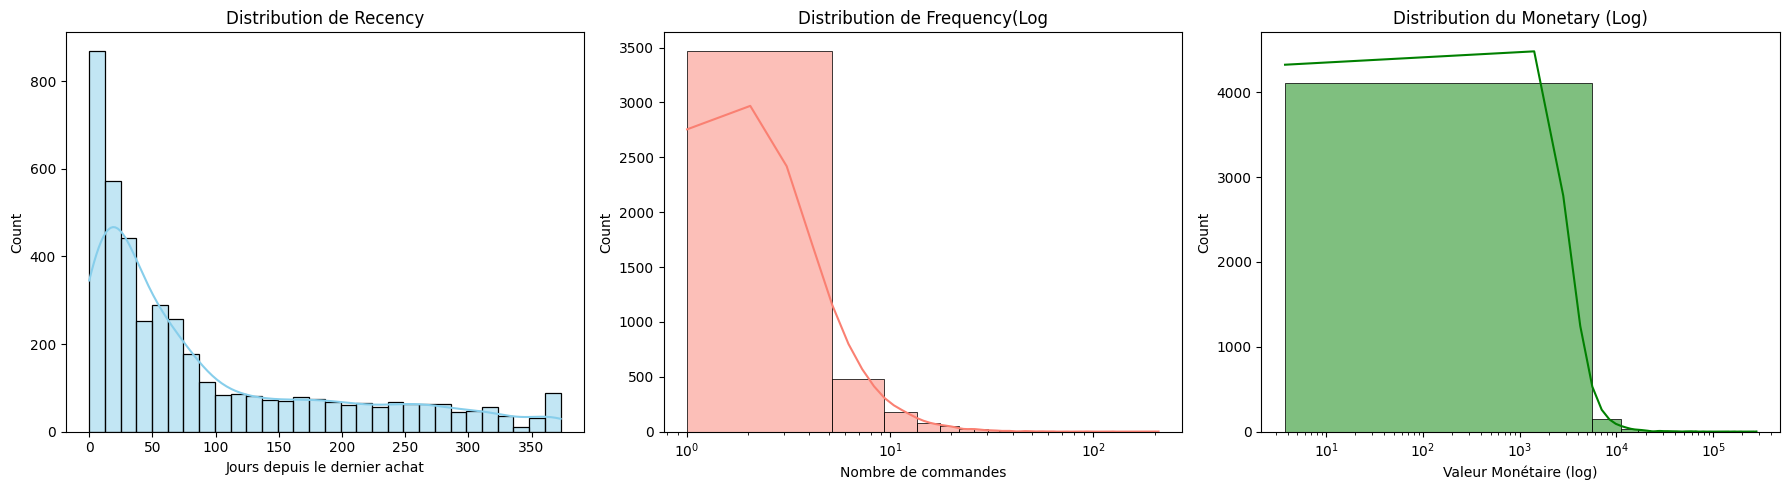

In [19]:
# 1. Conversion en Pandas pour la visualisation (données agrégées, donc gérable en mémoire)
rfm_pd = rfm_final.toPandas()

# 2. Configuration du graphique
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Distribution de la Récence ---
sns.histplot(rfm_pd['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution de Recency')
axes[0].set_xlabel('Jours depuis le dernier achat')

# --- Distribution de la Fréquence ---
# On limite l'axe X pour mieux voir la masse (exclusion visuelle des gros outliers)
sns.histplot(rfm_pd['Frequency'], bins=50, kde=True, ax=axes[1], color='salmon')
#axes[1].set_xlim(0, rfm_pd['Frequency'].quantile(0.95)) # Focus sur 95% des données
axes[1].set_xscale('log') 
axes[1].set_title('Distribution de Frequency(Log')
axes[1].set_xlabel('Nombre de commandes')

# --- Distribution du Montant (Monetary) ---
# Utilisation d'une échelle logarithmique car l'écart min/max est énorme
sns.histplot(rfm_pd['Monetary'], bins=50, kde=True, ax=axes[2], color='green')
axes[2].set_xscale('log') 
axes[2].set_title('Distribution du Monetary (Log)')
axes[2].set_xlabel('Valeur Monétaire (log)')

plt.tight_layout()
plt.show()

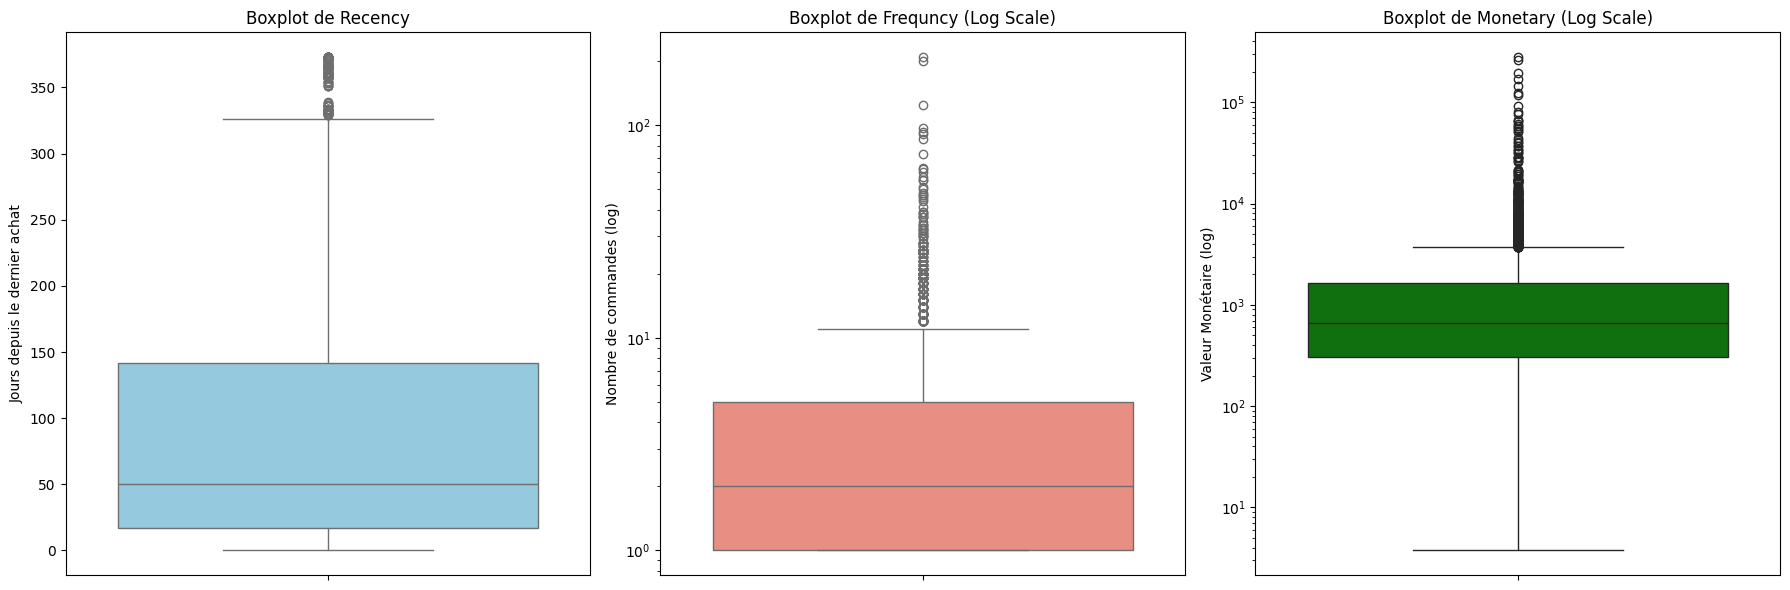

In [20]:
# 1. Préparation de la figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Boxplot de la Récence ---
sns.boxplot(y=rfm_pd['Recency'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot de Recency')
axes[0].set_ylabel('Jours depuis le dernier achat')

# --- Boxplot de la Fréquence (échelle Log) ---
sns.boxplot(y=rfm_pd['Frequency'], ax=axes[1], color='salmon')
axes[1].set_yscale('log')
axes[1].set_title('Boxplot de Frequncy (Log Scale)')
axes[1].set_ylabel('Nombre de commandes (log)')

# --- Boxplot du Montant (échelle Log) ---
sns.boxplot(y=rfm_pd['Monetary'], ax=axes[2], color='green')
axes[2].set_yscale('log')
axes[2].set_title('Boxplot de Monetary (Log Scale)')
axes[2].set_ylabel('Valeur Monétaire (log)')

plt.tight_layout()
plt.show()

In [21]:
# On regarde les tranches des gros clients
print("Répartition des gros clients :")
stats_outliers = rfm_final.select(
    F.count("*").alias("Total_Clients"),
    F.sum(F.when(F.col("Monetary") > 5000, 1).otherwise(0)).alias("Nb_plus_5k"),
    F.sum(F.when(F.col("Monetary") > 10000, 1).otherwise(0)).alias("Nb_plus_10k"),
    F.sum(F.when(F.col("Monetary") > 25000, 1).otherwise(0)).alias("Nb_plus_25k")
)

stats_outliers.show()

Répartition des gros clients :
+-------------+----------+-----------+-----------+
|Total_Clients|Nb_plus_5k|Nb_plus_10k|Nb_plus_25k|
+-------------+----------+-----------+-----------+
|         4338|       274|        104|         38|
+-------------+----------+-----------+-----------+



In [22]:
# 1. Création du dataset "Clean" pour le modèle
rfm_clean = rfm_final.filter(
    (F.col("Monetary") < 25000) & 
    (F.col("Frequency") < 100)
)

# 2. Vérification de l'impact sur la distribution
print(f"Clients conservés : {rfm_clean.count()} sur {rfm_final.count()}")
rfm_clean.select("Recency", "Frequency", "Monetary").summary("mean", "stddev", "min", "max").show()

Clients conservés : 4300 sur 4338
+-------+------------------+------------------+------------------+
|summary|           Recency|         Frequency|          Monetary|
+-------+------------------+------------------+------------------+
|   mean| 92.64651162790697|3.8948837209302325|1433.0172651162818|
| stddev|100.05620274274902| 4.977653890256804|2223.3729553914045|
|    min|                 0|                 1|              3.75|
|    max|               373|                93|          21429.39|
+-------+------------------+------------------+------------------+



In [23]:
# Etape 2 : Regrouper ces variables RFM dans un DataFrame PySpark par client

# 2. Regroupement des variables dans un seul vecteur "features"
# Assemblage des caractéristiques
assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary"], 
    outputCol="features"
)
rfm_vector = assembler.transform(rfm_clean)

# 2. Normalisation (Z-score scaling)
scaler = StandardScaler(
    inputCol="features", 
    outputCol="scaled_features", 
    withStd=True, 
    withMean=True
)
scaler_model = scaler.fit(rfm_vector)
rfm_scaled = scaler_model.transform(rfm_vector)

# Aperçu du vecteur normalisé
rfm_scaled.select("CustomerID", "scaled_features").show(5, truncate=False)

+----------+-------------------------------------------------------------+
|CustomerID|scaled_features                                              |
+----------+-------------------------------------------------------------+
|14450     |[0.8730442089301012,-0.17978022189969065,-0.4271740657873932]|
|15727     |[-0.7660345838325509,0.6238112065500753,1.6758514246782257]  |
|15790     |[-0.8260008811287454,-0.5815759361245736,-0.5461374629802125]|
|13285     |[-0.6960739036536571,0.021117635212750837,0.5739490227176371]|
|14570     |[1.8724824972000107,-0.38067807901213213,-0.5464478022772372]|
+----------+-------------------------------------------------------------+
only showing top 5 rows



 Recherche du K optimal avec GaussianMixture (GMM)...

K = 2 | LogLikelihood = -10147.36 | Silhouette = 0.6084
K = 3 | LogLikelihood = -8700.13 | Silhouette = 0.3306
K = 4 | LogLikelihood = -8036.91 | Silhouette = 0.2724
K = 5 | LogLikelihood = -6484.88 | Silhouette = 0.3701
K = 6 | LogLikelihood = -6203.49 | Silhouette = 0.3275
K = 7 | LogLikelihood = -5941.82 | Silhouette = 0.2996

 Recherche terminée!


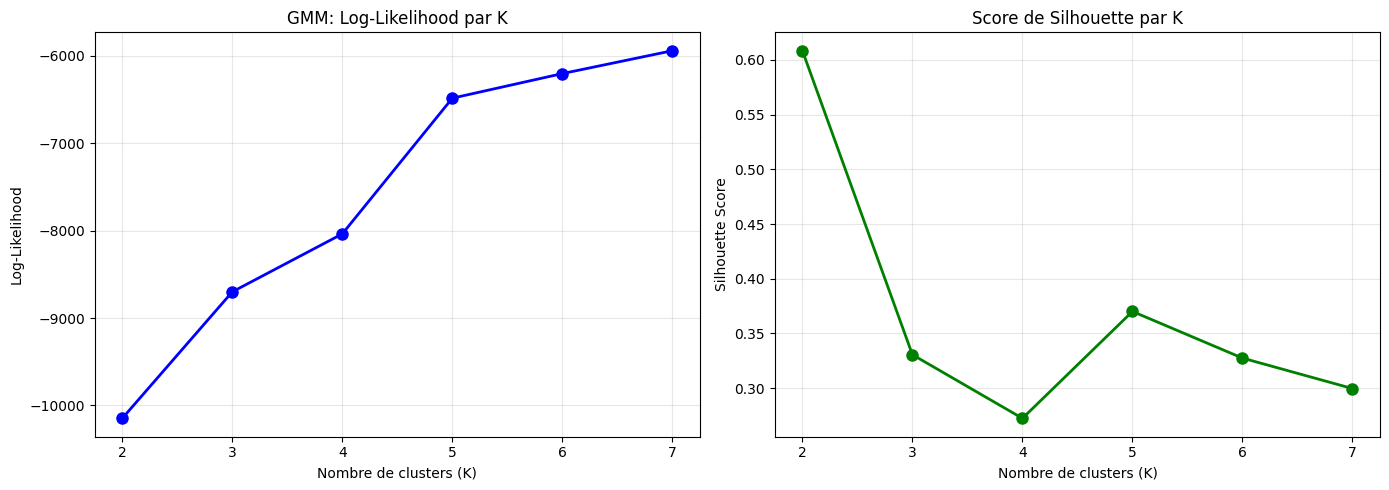


 Meilleur K recommandé: 2 (Silhouette=0.6084)


In [24]:
# 1. Recherche du nombre de clusters optimal
# Utilisation de GaussianMixture (GMM)
# Raison: BisectingKMeans donnait une inertie constante (bug détecté)

from pyspark.ml.evaluation import ClusteringEvaluator


cost = []
silhouette_scores = []

silhouette_evaluator = ClusteringEvaluator(
    featuresCol='scaled_features',
    predictionCol='Cluster',  
    metricName='silhouette'
)

print(' Recherche du K optimal avec GaussianMixture (GMM)...\n')

for k in range(2, 8):
    gmm = GaussianMixture(k=k, seed=42, featuresCol='scaled_features') \
            .setPredictionCol("Cluster")
    
    gmm_model = gmm.fit(rfm_scaled)
    predictions = gmm_model.transform(rfm_scaled)
    
    # Log-likelihood
    loglikelihood = gmm_model.summary.logLikelihood
    cost.append(loglikelihood)
    
    # Silhouette Score
    silhouette = silhouette_evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)
    
    print(f'K = {k} | LogLikelihood = {loglikelihood:.2f} | Silhouette = {silhouette:.4f}')

print('\n Recherche terminée!')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(2, 8), cost, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Nombre de clusters (K)')
ax1.set_ylabel('Log-Likelihood')
ax1.set_title('GMM: Log-Likelihood par K')
ax1.grid(True, alpha=0.3)

ax2.plot(range(2, 8), silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Nombre de clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Score de Silhouette par K')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = range(2, 8)[silhouette_scores.index(max(silhouette_scores))]
print(f'\n Meilleur K recommandé: {best_k} (Silhouette={max(silhouette_scores):.4f})')


In [25]:
# 3. Entraînement du modèle final 
print(f'Entraînement du modèle final GMM avec K={best_k}...')

model_final = GaussianMixture(k=best_k, seed=42, featuresCol='scaled_features').fit(rfm_scaled)
df_final_segmented = model_final.transform(rfm_scaled)

# 4. Analyse et Profilage des Segments 
# On groupe par prediction et on calcule les moyennes RFM
analysis = df_final_segmented.groupBy('prediction').agg(
    F.round(F.avg('Recency'), 1).alias('Moyenne_Récence'),
    F.round(F.avg('Frequency'), 1).alias('Moyenne_Fréquence'),
    F.round(F.avg('Monetary'), 2).alias('Moyenne_Montant'),
    F.count('CustomerID').alias('Nombre_de_Clients')
).orderBy('Moyenne_Montant', ascending=False) # On trie pour avoir les meilleurs en premier

print('\n Analyse des Segments:')
analysis.show()

# 5. Interprétation
print('\n Interprétation Métier des Segments:\n')

rows = analysis.collect()

# Définition des étiquettes selon le nombre de clusters trouvés
if len(rows) == 2:
    labels = ['Top acheteurs', ' Clients Standards / À réactiver']
else:
    labels = ['Champions', 'Fidèles', 'Occasionnels', 'À Risque', 'Perdus']

for i, row in enumerate(rows):
    # On prend le label dans la liste, sinon on utilise le numéro du cluster
    nom_segment = labels[i] if i < len(labels) else f"Segment {row['prediction']}"
    
    print(f"{nom_segment} (Cluster {row['prediction']}):")
    print(f"  • {row['Nombre_de_Clients']:,} clients")
    print(f"  • Récence: {row['Moyenne_Récence']} j | Fréquence: {row['Moyenne_Fréquence']} | Montant: {row['Moyenne_Montant']}€\n")

Entraînement du modèle final GMM avec K=2...

 Analyse des Segments:
+----------+---------------+-----------------+---------------+-----------------+
|prediction|Moyenne_Récence|Moyenne_Fréquence|Moyenne_Montant|Nombre_de_Clients|
+----------+---------------+-----------------+---------------+-----------------+
|         0|           28.7|              9.8|         4411.0|              916|
|         1|          110.0|              2.3|         626.92|             3384|
+----------+---------------+-----------------+---------------+-----------------+


 Interprétation Métier des Segments:

Top acheteurs (Cluster 0):
  • 916 clients
  • Récence: 28.7 j | Fréquence: 9.8 | Montant: 4411.0€

 Clients Standards / À réactiver (Cluster 1):
  • 3,384 clients
  • Récence: 110.0 j | Fréquence: 2.3 | Montant: 626.92€



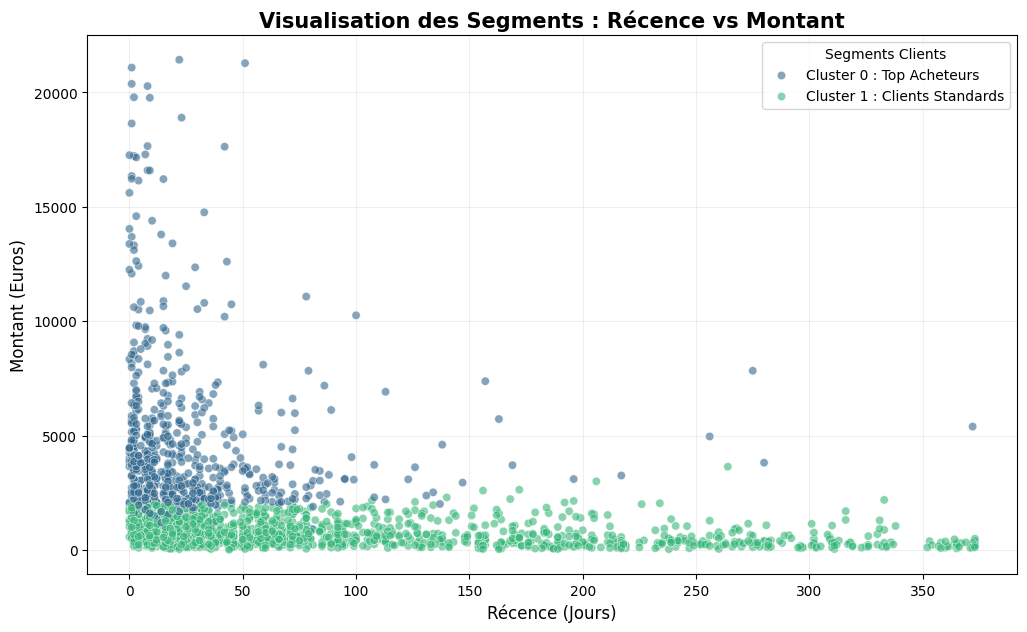

In [26]:
# On regarde quel cluster a le plus gros montant dans ton tableau 'analysis'
rows = analysis.collect()
# Le premier (index 0) est le "Top" car on a fait un .orderBy(ascending=False)
id_top = rows[0]['prediction']
id_standard = rows[1]['prediction']

mapping = {
    id_top: "Top Acheteurs",
    id_standard: "Clients Standards"
}

# 2. Conversion d'un échantillon pour la visualisation
df_viz = df_final_segmented.select("Recency", "Monetary", "prediction").limit(2000).toPandas()

# 3. Création du graphique
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(
    data=df_viz, 
    x='Recency', 
    y='Monetary', 
    hue='prediction', 
    palette='viridis',
    alpha=0.6
)

# 4. légende
handles, labels = scatter.get_legend_handles_labels()
new_labels = [f"Cluster {l} : {mapping[int(float(l))]}" for l in labels]
plt.legend(handles, new_labels, title='Segments Clients', loc='upper right')

plt.title('Visualisation des Segments : Récence vs Montant', fontsize=15, fontweight='bold')
plt.xlabel('Récence (Jours)', fontsize=12)
plt.ylabel('Montant (Euros)', fontsize=12)
plt.grid(True, alpha=0.2)

plt.show()

In [27]:
# Phase 4: Modélisation Supervisée
# 1. Préparation de la Cible (Label)
# On définit: 1 si Monetary > 2000, sinon 0
df_ml = df_final_segmented.withColumn('label', F.when(F.col('Monetary') > 2000, 1).otherwise(0))

# DIAGNOSTIC DU DÉSÉQUILIBRE 
print('Distribution des classes:')
class_dist = df_ml.groupBy('label').count().collect()
total = df_ml.count()
for row in class_dist:
    label_name = 'Gros dépensier (Cible)' if row['label'] == 1 else 'Petit dépensier'
    pct = (row['count'] / total) * 100
    print(f'  • {label_name}: {row["count"]:,} ({pct:.1f}%)')

# 2. Pipeline de Préparation
# IMPORTANT : On retire 'Monetary' des features pour éviter la triche (Data Leakage)
feature_cols = ['Recency', 'Frequency'] 

assembler = VectorAssembler(inputCols=feature_cols, outputCol='features_supervised')
df_ml_final = assembler.transform(df_ml).select('features_supervised', 'label')

# 3. Division Train / Test (70% / 30%)
train_df, test_df = df_ml_final.randomSplit([0.7, 0.3], seed=42)
print(f'\n Split effectué : {train_df.count():,} train / {test_df.count():,} test')



Distribution des classes:
  • Gros dépensier (Cible): 858 (20.0%)
  • Petit dépensier: 3,442 (80.0%)

 Split effectué : 3,077 train / 1,223 test


In [28]:
# 4. Entraînement : Random Forest 
rf = RandomForestClassifier(featuresCol='features_supervised', labelCol='label', numTrees=100, seed=42)
rf_model = rf.fit(train_df)

# 5. Prédiction sur l'échantillon test
predictions = rf_model.transform(test_df)

# 6. Évaluation via MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# On extrait les métriques spécifiquement pour la classe 1 (Gros dépensier)
# Spark ML permet d'isoler un label avec setMetricLabel
recall_gros = evaluator.setMetricLabel(1.0).evaluate(predictions, {evaluator.metricName: "truePositiveRateByLabel"})
precision_gros = evaluator.setMetricLabel(1.0).evaluate(predictions, {evaluator.metricName: "precisionByLabel"})
f1_gros = evaluator.setMetricLabel(1.0).evaluate(predictions, {evaluator.metricName: "fMeasureByLabel"})

print("RAPPORT DE PERFORMANCE (Classe : Gros Dépensier)")
print("-" * 45)
print(f" Rappel (Recall)    : {recall_gros:.2%}  <-- Capacité à capter les VIP")
print(f" Précision          : {precision_gros:.2%}  <-- Fiabilité de la prédiction VIP")
print(f" Score F1           : {f1_gros:.4f}  <-- Équilibre global")
print("-" * 45)

# --- 7. Matrice de Confusion via un Pivot (Évite les erreurs RDD/Py4J) ---
print("\n MATRICE DE CONFUSION :")
# On crée un tableau croisé dynamique entre Réel (label) et Prédit (prediction)
conf_matrix_df = predictions.groupBy("label").pivot("prediction", [0.0, 1.0]).count().na.fill(0).orderBy("label")

# 1. Extraction des données de la matrice de confusion
# .collect() transforme le DataFrame Spark en liste Python pour manipulation locale
conf_data = conf_matrix_df.collect()

# Décodage des coordonnées du tableau (Ligne = Réel, Colonne = Prédit) :
# [0][1] : Ligne 0 (Réel Petit), Colonne 1 (Prédit Petit) -> Succès
TN = conf_data[0][1] 

# [0][2] : Ligne 0 (Réel Petit), Colonne 2 (Prédit Gros) -> Erreur (Gaspillage marketing)
FP = conf_data[0][2] 

# [1][1] : Ligne 1 (Réel Gros),  Colonne 1 (Prédit Petit) -> Erreur (Opportunité manquée)
FN = conf_data[1][1] 

# [1][2] : Ligne 1 (Réel Gros),  Colonne 2 (Prédit Gros) -> Succès (VIP capté)
TP = conf_data[1][2] 

# 2. Affichage graphique de la Matrice de Confusion
# Le formatage {:<7} permet d'aligner les chiffres proprement en colonnes
print("\n RÉALITÉ DU TERRAIN (MATRICE DE CONFUSION) :")
print("                  Prédit: Petit | Prédit: Gros")
print(f"Réel: Petit      |      {int(TN):<7} | {int(FP):<10}")
print(f"Réel: Gros       |      {int(FN):<7} | {int(TP):<10}")

# 3. Verdict Stratégique
# On analyse le 'Recall' (Rappel) : notre capacité à ne pas oublier de VIP.
print("\n VERDICT DU MODÈLE :")

if recall_gros > 0.85:
    # Très bon taux de détection
    print(" Le modèle détecte très bien les gros dépensiers.")
    
elif recall_gros < 0.60:
    # Taux de détection faible
    print(" Le modèle est trop prudent : il rate beaucoup de gros dépensiers.")
    print(f"    Conséquence : {int(FN)} clients importants n'ont pas été repérés.")

RAPPORT DE PERFORMANCE (Classe : Gros Dépensier)
---------------------------------------------
 Rappel (Recall)    : 59.57%  <-- Capacité à capter les VIP
 Précision          : 82.04%  <-- Fiabilité de la prédiction VIP
 Score F1           : 0.6902  <-- Équilibre global
---------------------------------------------

 MATRICE DE CONFUSION :

 RÉALITÉ DU TERRAIN (MATRICE DE CONFUSION) :
                  Prédit: Petit | Prédit: Gros
Réel: Petit      |      963     | 30        
Réel: Gros       |      93      | 137       

 VERDICT DU MODÈLE :
 Le modèle est trop prudent : il rate beaucoup de gros dépensiers.
    Conséquence : 93 clients importants n'ont pas été repérés.


In [29]:
# 6. Optimisation des hyperparamètres

# 1. Grille des paramètres à tester
paramGrid = (ParamGridBuilder()
             .addGrid(rf.maxDepth, [5, 10, 20])      # Teste différentes profondeurs d'arbres
             .addGrid(rf.numTrees, [20, 50, 100])    # Teste différentes quantités d'arbres
             .build())

# 2. Définition de l'évaluateur (AUC)
# L'AUC mesure la capacité du modèle à bien séparer les deux classes
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")

# 3. Configuration de la validation croisée (Cross-Validation)
# On divise les données en 3 pour tester chaque combinaison de paramètres
cv = CrossValidator(estimator=rf,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator_auc,
                    numFolds=3,
                    seed=42)

# 4. Entraînement pour trouver la meilleure combinaison
print("Recherche des meilleurs paramètres en cours...")
cv_model = cv.fit(train_df)

# 5. Récupération du meilleur modèle trouvé
best_rf = cv_model.bestModel

# 6. Prédictions et calcul du score final
best_predictions = best_rf.transform(test_df)
final_auc = evaluator_auc.evaluate(best_predictions)

print("-" * 30)
print(f" AUC finale : {final_auc:.4f}")
print(f" Meilleure profondeur : {best_rf.getOrDefault('maxDepth')}")
print(f" Meilleur nombre d'arbres : {best_rf.getOrDefault('numTrees')}")
print("-" * 30)

Recherche des meilleurs paramètres en cours...
------------------------------
 AUC finale : 0.9180
 Meilleure profondeur : 5
 Meilleur nombre d'arbres : 100
------------------------------


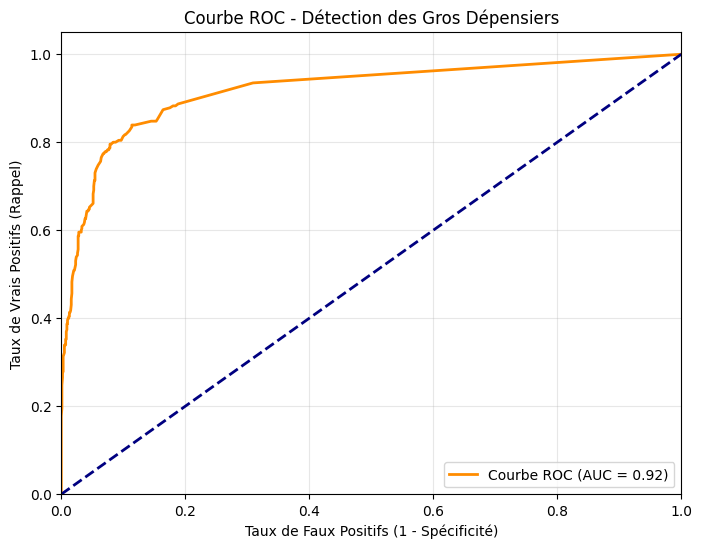

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 1. Calcul de l'AUC globale avec Spark
evaluator_roc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="probability", metricName="areaUnderROC")
auc_score = evaluator_roc.evaluate(predictions)

# 2. Extraction des probabilités pour la classe 1 (Gros Dépensier)
# Spark stocke les probabilités dans un vecteur [prob_0, prob_1]
# On utilise un "UDF" ou on extrait simplement via pandas pour le traçage
results = predictions.select("label", "probability").toPandas()
results['prob_1'] = results['probability'].apply(lambda x: float(x[1]))

# 3. Calcul des points de la courbe ROC (False Positive Rate & True Positive Rate)
fpr, tpr, thresholds = roc_curve(results['label'], results['prob_1'])

# 4. Affichage graphique
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Ligne de chance (aléatoire)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Rappel)')
plt.title('Courbe ROC - Détection des Gros Dépensiers')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [31]:
# Calcul du nouveau rappel avec le meilleur modèle
evaluator_final = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
new_recall = evaluator_final.setMetricLabel(1.0).evaluate(best_predictions, {evaluator_final.metricName: "truePositiveRateByLabel"})

print(f" Ancien Rappel : 59.57%")
print(f" Nouveau Rappel : {new_recall:.2%}")

# Affichage de la nouvelle matrice de confusion
print("\n NOUVELLE MATRICE DE CONFUSION (Modèle Optimisé) :")
best_predictions.groupBy("label").pivot("prediction", [0.0, 1.0]).count().na.fill(0).orderBy("label").show()

 Ancien Rappel : 59.57%
 Nouveau Rappel : 59.57%

 NOUVELLE MATRICE DE CONFUSION (Modèle Optimisé) :
+-----+---+---+
|label|0.0|1.0|
+-----+---+---+
|    0|963| 30|
|    1| 93|137|
+-----+---+---+



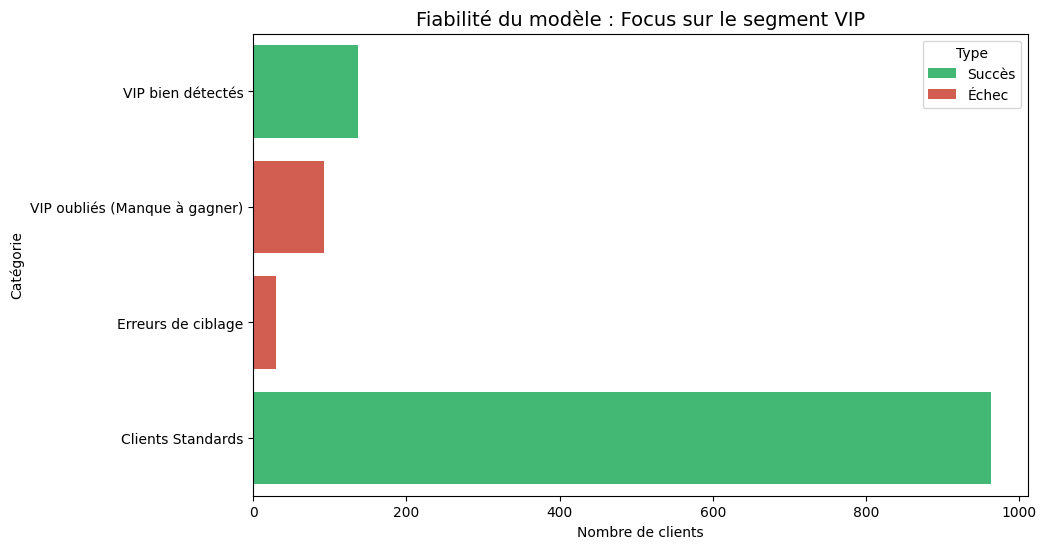

In [32]:
# Préparation des données depuis la matrice de confusion
data = {
    'Catégorie': ['VIP bien détectés', 'VIP oubliés (Manque à gagner)', 'Erreurs de ciblage', 'Clients Standards'],
    'Nombre': [137, 93, 30, 963],
    'Type': ['Succès', 'Échec', 'Échec', 'Succès']
}
df_plot = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Nombre', y='Catégorie', hue='Type', palette={'Succès': '#2ecc71', 'Échec': '#e74c3c'})
plt.title("Fiabilité du modèle : Focus sur le segment VIP", fontsize=14)
plt.xlabel("Nombre de clients")
plt.show()

In [33]:
# Fermeture propre de Spark
print('\n Fermeture de la SparkSession...')
spark.stop()
print('Projet terminé avec succès!')


 Fermeture de la SparkSession...
Projet terminé avec succès!
